#ANALISI DIFFUSIONE COVID 19
Il committente richiede di avere un report su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare il dataset, curato da Our World in Data, all'indirizzo https://github.com/owid/covid-19-data/tree/master/public/data

In [2]:
# importo le librerie che mi servono
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# importo il dataset
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
covid = pd.read_csv(url)

# visualizzo 10 righe casuali del dataset
covid.sample(10)

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
356374,ZAF,Africa,South Africa,2021-05-03,1582842.0,0.0,1210.29,54406.0,0.0,40.14,...,33.2,43.99,2.32,64.13,0.71,59893884,NaN,NaN,NaN,NaN
409315,OWID_UMC,NaN,Upper-middle-income countries,2023-03-27,248748263.0,0.0,27993.43,2808515.0,0.0,145.00,...,NaN,NaN,NaN,NaN,NaN,2525921300,NaN,NaN,NaN,NaN
119380,OWID_EUR,NaN,Europe,2022-03-26,171330517.0,0.0,767244.86,1795796.0,0.0,1970.57,...,NaN,NaN,NaN,NaN,NaN,744807803,NaN,NaN,NaN,NaN
26985,BHS,North America,Bahamas,2020-07-10,104.0,0.0,0.00,11.0,0.0,0.00,...,20.4,NaN,2.90,73.92,0.81,409989,NaN,NaN,NaN,NaN
214456,LIE,Europe,Liechtenstein,2021-12-25,5791.0,0.0,43.43,69.0,0.0,0.29,...,NaN,NaN,2.40,82.49,0.92,39355,NaN,NaN,NaN,NaN
348249,SXM,North America,Sint Maarten (Dutch part),2022-01-03,5197.0,0.0,64.14,75.0,0.0,0.00,...,NaN,NaN,NaN,78.95,NaN,44192,NaN,NaN,NaN,NaN
145170,GIB,Europe,Gibraltar,2023-11-16,20550.0,0.0,0.00,113.0,0.0,0.00,...,NaN,NaN,NaN,79.93,NaN,32677,NaN,NaN,NaN,NaN
116998,ETH,Africa,Ethiopia,2020-04-17,69.0,0.0,4.43,23.0,0.0,3.29,...,8.5,7.96,0.30,66.60,0.48,123379928,NaN,NaN,NaN,NaN
144263,GIB,Europe,Gibraltar,2021-05-23,4286.0,0.0,0.00,94.0,0.0,0.00,...,NaN,NaN,NaN,79.93,NaN,32677,NaN,NaN,NaN,NaN
84281,CIV,Africa,Cote d'Ivoire,2021-07-25,49554.0,429.0,61.29,324.0,4.0,0.57,...,NaN,19.35,NaN,57.78,0.54,28160548,NaN,NaN,NaN,NaN


In [4]:
# ESERCIZIO 1: Si richiede di verificare le dimensioni del dataset e i relativi metadati
print("La dimensione del dataset è:")
print("Righe, Colonne")
print(covid.shape)

print()
print("I metadati sono:")
covid.info()

La dimensione del dataset è:
Righe, Colonne
(429435, 67)

I metadati sono:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64


In [5]:
# analizzo le colonne numeriche
covid.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,4.118040e+05,4.101590e+05,4.089290e+05,4.118040e+05,410608.000000,409378.000000,411804.000000,410159.000000,408929.000000,411804.000000,...,243817.000000,161741.000000,290689.000000,390299.000000,319127.000000,4.294350e+05,1.341100e+04,13411.000000,13411.000000,13411.000000
mean,7.365292e+06,8.017360e+03,8.041026e+03,8.125957e+04,71.852139,72.060828,112096.199420,122.357073,122.713852,835.514337,...,33.097758,50.649390,3.106895,73.702098,0.722178,1.520336e+08,5.604765e+04,9.766431,10.925353,1772.666404
std,4.477582e+07,2.296649e+05,8.661611e+04,4.411901e+05,1368.322990,513.636565,162240.412405,1508.778585,559.701663,1134.932641,...,13.853952,31.905236,2.549168,7.387914,0.149237,6.975408e+08,1.568691e+05,12.040658,24.560706,1991.892770
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.190000,0.100000,53.280000,0.390000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2936.450000
25%,6.280750e+03,0.000000e+00,0.000000e+00,4.300000e+01,0.000000,0.000000,1916.100000,0.000000,0.000000,24.570000,...,22.600000,20.860000,1.300000,69.500000,0.600000,5.237980e+05,1.765000e+02,2.060000,-1.500000,116.875000
50%,6.365300e+04,0.000000e+00,1.200000e+01,7.990000e+02,0.000000,0.000000,29145.480000,0.000000,2.790000,295.090000,...,33.100000,49.540000,2.500000,75.050000,0.740000,6.336393e+06,6.815200e+03,8.130000,5.660000,1270.800000
75%,7.582720e+05,0.000000e+00,3.132900e+02,9.574000e+03,0.000000,3.140000,156770.190000,0.000000,56.250000,1283.820000,...,41.500000,82.500000,4.210000,79.460000,0.830000,3.296952e+07,3.912804e+04,15.160000,15.575000,2883.025000
max,7.758668e+08,4.423623e+07,6.319461e+06,7.057132e+06,103719.000000,14817.000000,763598.600000,241758.230000,34536.890000,6601.110000,...,78.100000,100.000000,13.800000,86.750000,0.960000,7.975105e+09,1.349776e+06,78.080000,378.220000,10293.520000


In [6]:
# visualizzo i dati nulli del dataset
for column in covid.columns:
    nan_count=covid[column].isna().sum()
    nan_perc=round((nan_count/covid.shape[0])*100,2)
    print(f"La colonna {column} contiene {nan_count} valori NaN, ossia il {nan_perc}% dei valori")

La colonna iso_code contiene 0 valori NaN, ossia il 0.0% dei valori
La colonna continent contiene 26525 valori NaN, ossia il 6.18% dei valori
La colonna location contiene 0 valori NaN, ossia il 0.0% dei valori
La colonna date contiene 0 valori NaN, ossia il 0.0% dei valori
La colonna total_cases contiene 17631 valori NaN, ossia il 4.11% dei valori
La colonna new_cases contiene 19276 valori NaN, ossia il 4.49% dei valori
La colonna new_cases_smoothed contiene 20506 valori NaN, ossia il 4.78% dei valori
La colonna total_deaths contiene 17631 valori NaN, ossia il 4.11% dei valori
La colonna new_deaths contiene 18827 valori NaN, ossia il 4.38% dei valori
La colonna new_deaths_smoothed contiene 20057 valori NaN, ossia il 4.67% dei valori
La colonna total_cases_per_million contiene 17631 valori NaN, ossia il 4.11% dei valori
La colonna new_cases_per_million contiene 19276 valori NaN, ossia il 4.49% dei valori
La colonna new_cases_smoothed_per_million contiene 20506 valori NaN, ossia il 4.78%

In [7]:
# controllo quanti valori unici ci sono nelle colonne continent e location
unique_continent = covid["continent"].nunique()
unique_location = covid["location"].nunique()
print(f"Il dataset contiene {unique_continent} continenti")
print(f"Il dataset contiene {unique_location} location")
print()

# controllo le istanze per le colonne continent e location
count_continent = covid["continent"].value_counts()
count_location = covid["location"].value_counts()
print(count_continent)
print()
print(count_location)

Il dataset contiene 6 continenti
Il dataset contiene 255 location

continent
Africa           95419
Europe           91031
Asia             84199
North America    68638
Oceania          40183
South America    23440
Name: count, dtype: int64

location
High-income countries            3026
European Union (27)              3024
Upper-middle-income countries    3013
Lower-middle-income countries    2983
Low-income countries             2724
                                 ... 
Scotland                         1305
Wales                            1198
Macao                             795
Northern Cyprus                   691
Western Sahara                      1
Name: count, Length: 255, dtype: int64


In [8]:
# analizzo le colonne new_cases e total_cases
covid[["new_cases", "total_cases"]].value_counts()

new_cases   total_cases
0.0         0.0            29304
            1.0             1584
            26.0            1571
            4.0             1464
            3.0              954
                           ...  
133.0       2134.0             1
            4153.0             1
            5535.0             1
            11160.0            1
44236227.0  704630839.0        1
Name: count, Length: 77655, dtype: int64

In [9]:
# ESERCIZIO 2: Si chiede di trovare, per ogni continente:

# 2.a: il numero di casi fin dall'inizio della pandemia
# calcolo il numero totale di casi per continente
print("Numero totale di casi per continente:")
tot_cases_continent = covid.groupby("continent")["new_cases"].sum().sort_values(ascending=False)
print(tot_cases_continent)
print()

# 2.b: la percentuale rispetto al totale mondiale del numero di casi
# trovo il totale mondiale
tot_cases_world = tot_cases_continent.sum()
print("Il totale dei casi nel mondo è:", tot_cases_world)
print()

# calcolo la percentuale di casi per ogni continente
perc_cases_continent = round((tot_cases_continent / tot_cases_world) * 100, 2)
print("Percentuale di casi per continente:")
print(perc_cases_continent)

Numero totale di casi per continente:
continent
Asia             301564180.0
Europe           252916868.0
North America    124492698.0
South America     68811012.0
Oceania           15003468.0
Africa            13146831.0
Name: new_cases, dtype: float64

Il totale dei casi nel mondo è: 775935057.0

Percentuale di casi per continente:
continent
Asia             38.86
Europe           32.60
North America    16.04
South America     8.87
Oceania           1.93
Africa            1.69
Name: new_cases, dtype: float64


<Axes: title={'center': 'Nuovi casi Covid in Italia nel 2022'}, xlabel='Data', ylabel='Nuovi Casi'>

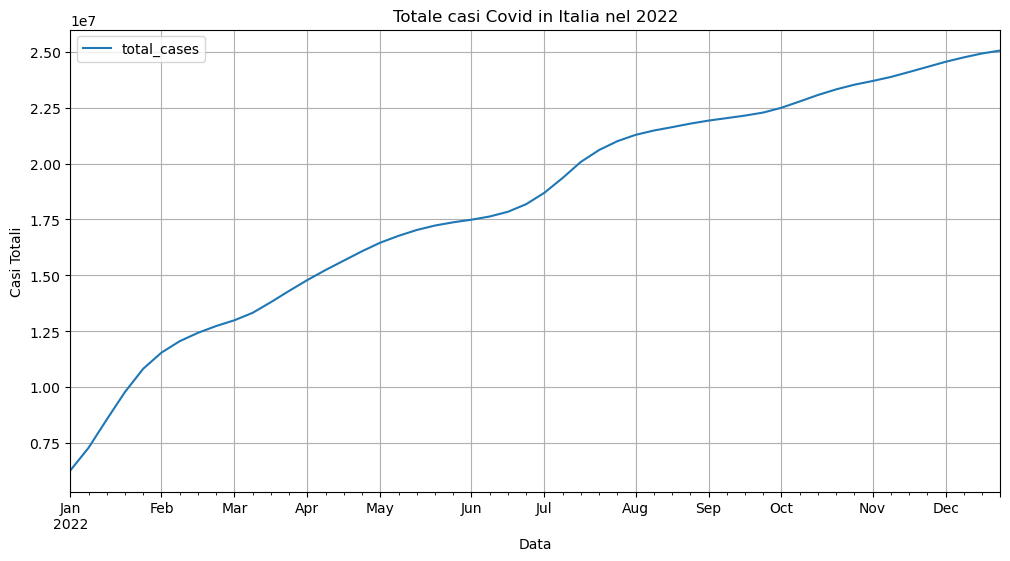

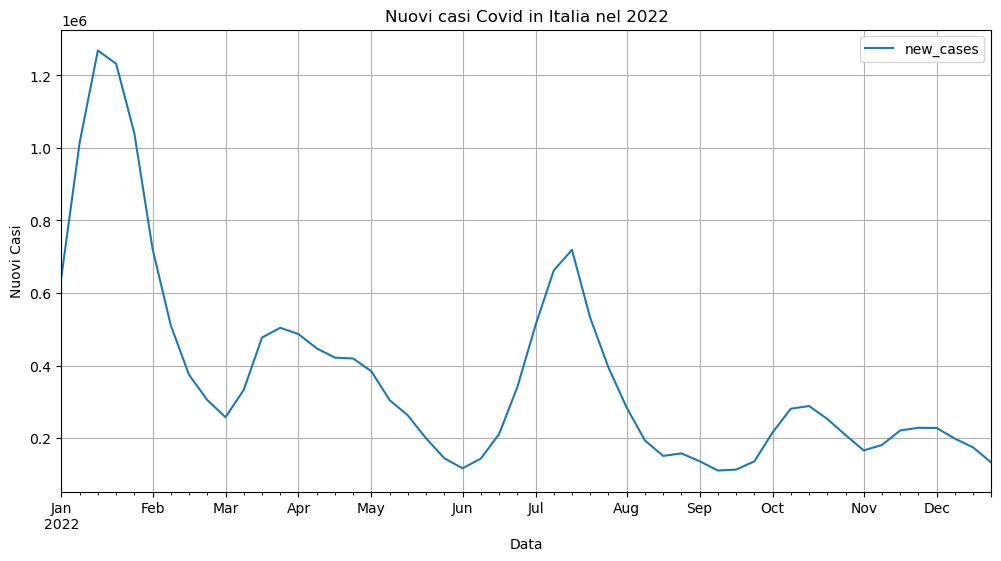

In [10]:
# ESERCIZIO 3: Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente,
# filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati:

# 3.a: l'evoluzione del casi totali dall'inizio alla fine dell'anno
# converto il datatype della colonna "date" in "datetime"
covid["date"] = pd.to_datetime(covid["date"])

# filtro per location e per anno
italia_2022 = covid[(covid["location"] == "Italy") & (covid["date"].dt.year == 2022)]

# rimuovo i giorni null ed includo solo i "new cases" maggiori di 0
italia_2022 = italia_2022[italia_2022["new_cases"].notna() & italia_2022["new_cases"] > 0]

# creo il grafico dei casi totali in italia nel 2022
italia_2022.plot(figsize = (12, 6), x = "date", xlabel = "Data", y = "total_cases", ylabel = "Casi Totali", kind = "line", title = "Totale casi Covid in Italia nel 2022", grid = True)

# 3.b: il numero di nuovi casi rispetto alla data
# creo il grafico dei nuovi casi in italia nel 2022
italia_2022.plot(figsize = (12, 6), x = "date", xlabel = "Data", y = "new_cases", ylabel = "Nuovi Casi", kind = "line", title = "Nuovi casi Covid in Italia nel 2022", grid = True)

"Il grafico mostra che Francia e Germania hanno avuto mediamente molti più pazienti in terapia intensiva rispetto all'Italia.\nL'Italia è inoltre lo stato che presenta la variabilità più bassa, con picchi nettamente inferiori rispetto a Francia e Germania."

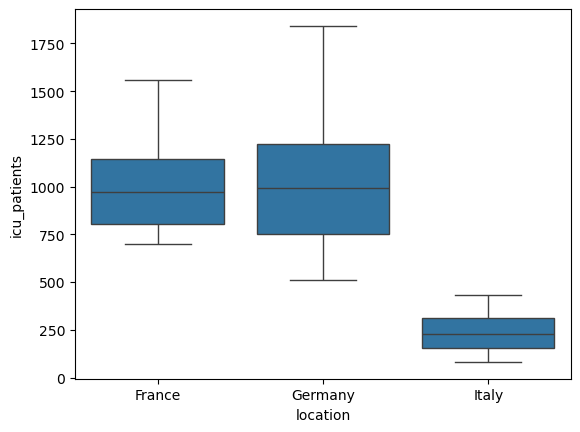

In [27]:
# ESERCIZIO 4: Riguardo le nazioni di Italia, Germania e Francia:abs
# 4.a: mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva
# (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso)
# filtro per location e per data
icu = covid[(covid["location"].isin(["Italy", "Germany", "France"])) & (covid["date"].between("2022-05-01", "2023-04-30"))]

# rimuovo i valori nulli
icu = icu[["location", "date", "icu_patients"]].dropna()

# creo il grafico dei pazienti in terapia intensiva
sns.boxplot(x = "location", y = "icu_patients", data = icu)

# 4.b: scrivere un breve commento (una o due righe) riguardo che conclusioni possiamo trarre osservando il grafico risultante
'''Il grafico mostra che Francia e Germania hanno avuto mediamente molti più pazienti in terapia intensiva rispetto all'Italia.
L'Italia è inoltre lo stato che presenta la variabilità più bassa, con picchi nettamente inferiori rispetto a Francia e Germania.'''

Totale pazienti ospedalizzati nel 2021: location
France     6008717.0
Germany          NaN
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64



<Axes: title={'center': 'Pazienti ospedalizzati (Italia, Germania, Francia, Spagna 2021)'}, xlabel='Paese', ylabel='Pazienti'>

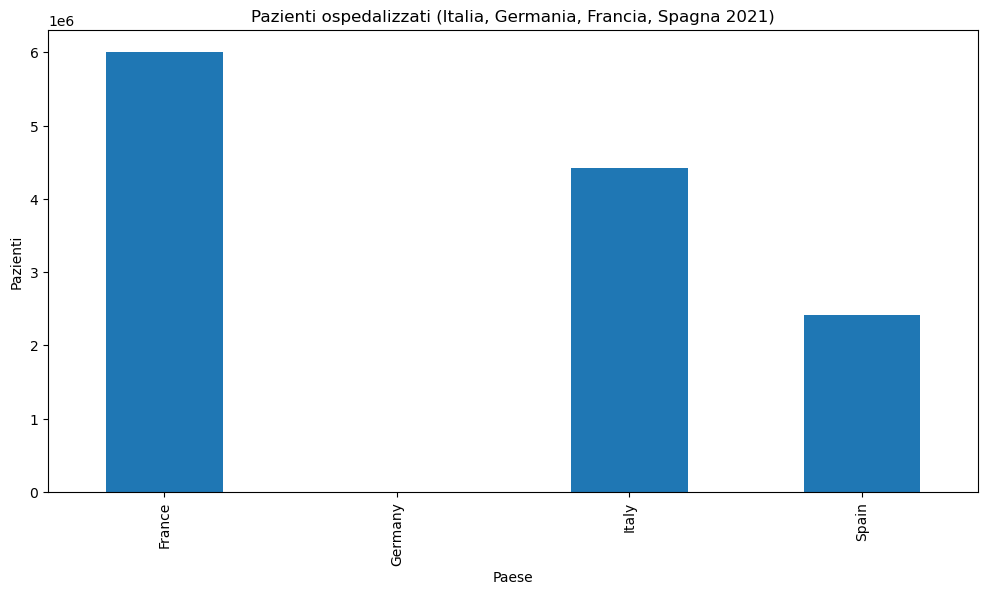

In [28]:
# ESERCIZIO 5: Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:
# 5.a: mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna hosp_patients)
# creo il filtro richiesto
tot_hosp_patients = covid[(covid["location"].isin(["Italy", "Germany", "Spain", "France"])) & (covid["date"].dt.year == 2021)]

# raggruppo i dati per "location" ed escludo i dati nulli
tot_hosp_patients = tot_hosp_patients.groupby("location")["hosp_patients"].sum(min_count = 1)
print("Totale pazienti ospedalizzati nel 2021:", tot_hosp_patients)
print()

# creo un grafico con i dati raccolti
tot_hosp_patients.plot(figsize = (12, 6), x = "location", xlabel = "Paese", y = "hosp_patients", ylabel = "Pazienti", kind = "bar", title = "Pazienti ospedalizzati (Italia, Germania, Francia, Spagna 2021)")

# 5.b: se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno
# Dal grafico e dai dati raccolti, possiamo vedere come manchino del tutto i dati sui pazienti ospedalizzati per la Germania.
# Se fossero mancati solo pochi dati, avremmo potuto usare uno dei metodi per stimarli, riempirli o interpolarli, ma siccome mancano del tutto, ho preferito rimuoverli.
# L'alternativa sarebbe stata quella di trovare un file con i dati mancanti e di effettuare una merge tra i due dataset.